1
A cnn uses a convolutional layer that helps with feature extraction. These layers apply filters on the input, helping the model detect patterns and features. In a 2d convolutional layer (the one we are using in this problem set and project), a kernel slides over the input data (in our case an image) and combines the values it is currently on using elementwise multiplication into a single output. This is repeated as it is slid over the input. Feed forward networks do not use convolutional layers. 

CNNs are useful for computer vision problems because they can learn spatial relationships within images, they help with dimensionality reduction, and the overlapping that occurs when the step the kernel takes is smaller than its size helps it capture fine details and patterns that span multiple pixels. 

An autoencoder is a type of neural network that is trained to compress and then decompress data. This process is called encoding and decoding. 

By using non linear activation functions (relu), the autoencoder can learn complex and non linear mappings between the input and latent space. 

If the autoencoder uses linear activation functions, the autoencoder can be used for linear dimensionality reduction. When an autoencoder that uses linear activation functions uses MSE (mean squared error) as the reconstruction loss, it minimizes the squared difference between input and reconstruction. This is almost identical to the reconstruction error in PCA. 

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Model, models
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import os
from PIL import Image
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [14]:
# Load and preprocess images
def load_and_preprocess_images(folder_path, target_size=(64, 64)):  # Change target size to 64x64
    images = []
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = load_img(img_path, target_size=target_size)
        img_array = img_to_array(img) / 255.0  # Normalize to [0, 1]
        images.append(img_array)
    return np.array(images)

# Load Lightning and Rainbow class images
lightning_images = load_and_preprocess_images('dataset1/dew')
rainbow_images = load_and_preprocess_images('dataset1/sandstorm')

# Combine the datasets
all_images = np.concatenate([lightning_images, rainbow_images])

# Split the dataset into training and validation sets
X_train, X_val = train_test_split(all_images, test_size=0.2, random_state=42)

# Define the Autoencoder model
def build_autoencoder(input_shape, latent_dim):
    # Encoder
    encoder_input = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)  # 64x64 -> 32x32
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)  # 32x32 -> 16x16
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)  # 16x16 -> 8x8
    x = layers.Flatten()(x)
    encoder_output = layers.Dense(latent_dim)(x)

    encoder = models.Model(encoder_input, encoder_output, name='encoder')

    # Decoder
    decoder_input = layers.Input(shape=(latent_dim,))
    x = layers.Dense(8 * 8 * 128, activation='relu')(decoder_input)  # Adjust for 8x8 feature maps
    x = layers.Reshape((8, 8, 128))(x)
    x = layers.Conv2DTranspose(128, (3, 3), strides=2, activation='relu', padding='same')(x)  # 8x8 -> 16x16
    x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same')(x)   # 16x16 -> 32x32
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)   # 32x32 -> 64x64
    decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)        # Output 64x64x3

    decoder = models.Model(decoder_input, decoder_output, name='decoder')

    # Autoencoder
    autoencoder_input = layers.Input(shape=input_shape)
    encoded = encoder(autoencoder_input)
    decoded = decoder(encoded)
    autoencoder = models.Model(autoencoder_input, decoded, name='autoencoder')

    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder, decoder

# Latent dimensions to test
latent_dims = [2, 8, 16, 32]
input_shape = X_train.shape[1:]  # This will now be (64, 64, 3)
reconstructed_images_dict = {}  # To store reconstructed images for each latent dimension

# Train and evaluate Autoencoder for each latent dimension
for latent_dim in latent_dims:
    print(f"Training Autoencoder with latent dimension: {latent_dim}")
    
    # Build the Autoencoder
    autoencoder, encoder, decoder = build_autoencoder(input_shape, latent_dim)

    # Train the Autoencoder
    history = autoencoder.fit(X_train, X_train,
                              epochs=50,
                              batch_size=32,
                              validation_data=(X_val, X_val),
                              verbose=0)  # Suppress training output for clarity

    # Reconstruct images from the validation set
    reconstructed_images = autoencoder.predict(X_val)
    reconstructed_images_dict[latent_dim] = reconstructed_images  # Save reconstructed images

# Function to plot reconstructed images
def plot_reconstructed_images(original_images, reconstructed_images, latent_dim, n=5):
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Display original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original_images[i])
        plt.title("Original")
        plt.axis('off')

        # Display reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed_images[i])
        plt.title(f"Reconstructed (Latent Dim = {latent_dim})")
        plt.axis('off')
    plt.show()

# Plot reconstructed images for each latent dimension
for latent_dim in latent_dims:
    print(f"Reconstructed Images for Latent Dimension = {latent_dim}")
    plot_reconstructed_images(X_val, reconstructed_images_dict[latent_dim], latent_dim)

Training Autoencoder with latent dimension: 2


KeyboardInterrupt: 

In [5]:
def load_and_preprocess_images(folder_path, target_size=(64, 64)):
    images = []
    labels = []
    classes = ['sandstorm', 'lightning', 'hail', 'rain', 'snow', 'frost']
    
    # Create a dictionary to map class names to numeric labels
    class_to_label = {class_name: idx for idx, class_name in enumerate(classes)}
    
    for class_name in classes:
        class_path = os.path.join(folder_path, class_name)
        if not os.path.exists(class_path):
            continue
            
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            img = load_img(img_path, target_size=target_size)
            img_array = img_to_array(img) / 255.0  # Normalize to [0, 1]
            images.append(img_array)
            labels.append(class_to_label[class_name])
    
    return np.array(images), np.array(labels)

def create_cnn_model(input_shape=(64, 64, 3), num_classes=6):
    model = Sequential([
        # First Convolutional Block
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Second Convolutional Block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Third Convolutional Block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Flatten and Dense Layers
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Main execution
def train_weather_cnn(data_folder, epochs=10, batch_size=32):
    # Load and preprocess images
    X, y = load_and_preprocess_images(data_folder)
    
    # Convert labels to one-hot encoding
    y = to_categorical(y)
    
    # Split the data
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Create and compile the model
    model = create_cnn_model()
    
    # Print model summary
    model.summary()
    
    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    # Train the model
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping]
    )
    
    # Plot training history
    plt.figure(figsize=(12, 4))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return model, history

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,488,742 (17.12 MB)

 Trainable params: 4,486,822 (17.12 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 41s 388ms/step - accuracy: 0.5878 - loss: 1.4139 - val_accuracy: 0.2466 - val_loss: 5.1536
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 38s 344ms/step - accuracy: 0.7003 - loss: 0.8641 - val_accuracy: 0.2466 - val_loss: 6.4073
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 27s 320ms/step - accuracy: 0.7318 - loss: 0.7972 - val_accuracy: 0.5434 - val_loss: 1.4855
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 30s 367ms/step - accuracy: 0.7637 - loss: 0.6657 - val_accuracy: 0.5084 - val_loss: 1.9694
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 28s 336ms/step - accuracy: 0.7884 - loss: 0.6024 - val_accuracy: 0.5860 - val_loss: 1.3399
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 26s 309ms/step - accuracy: 0.7994 - loss: 0.5471 - val_accuracy: 0.5967 - val_loss: 1.2616
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 26s 307ms/step - accuracy: 0.8502 - loss: 0.4385 - val_accuracy: 0.6758 - val_loss: 1.1433
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 25s 306ms/step - accuracy: 0.8585 - loss: 0.4015 - val_accu

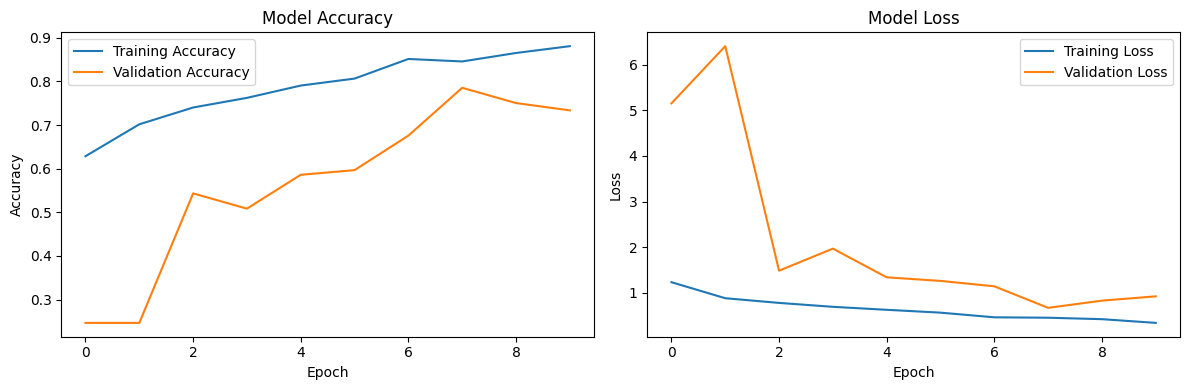

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step


NameError: name 'sns' is not defined

<Figure size 1000x800 with 0 Axes>

In [7]:
def evaluate_model(model, data_folder, test_size=0.2):
    # Load and preprocess all images
    X, y = load_and_preprocess_images(data_folder)
    
    # Get class names (assuming they're the folder names)
    classes = ['sandstorm', 'lightning', 'hail', 'rain', 'snow', 'frost']
    
    # Convert labels to one-hot encoding
    y_one_hot = to_categorical(y)
    
    # Split the data - use the same seed as training for consistency
    _, X_test, _, y_test_one_hot = train_test_split(X, y_one_hot, test_size=test_size, random_state=42)
    _, _, _, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    
    # Get predictions
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=classes))
    
    # Calculate and print additional metrics
    test_loss, test_accuracy = model.evaluate(X_test, y_test_one_hot, verbose=0)
    print("\nOverall Test Metrics:")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Loss: {test_loss:.4f}")
    
    # Calculate per-class accuracy
    per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
    print("\nPer-class Accuracy:")
    for class_name, accuracy in zip(classes, per_class_accuracy):
        print(f"{class_name}: {accuracy:.4f}")
    
    # Calculate and print misclassification analysis
    print("\nMost Common Misclassifications:")
    for i in range(len(classes)):
        for j in range(len(classes)):
            if i != j and cm[i][j] > 0:
                print(f"{classes[i]} misclassified as {classes[j]}: {cm[i][j]} times")
                
    return {
        'confusion_matrix': cm,
        'test_accuracy': test_accuracy,
        'test_loss': test_loss,
        'per_class_accuracy': per_class_accuracy
    }

def analyze_worst_predictions(model, data_folder, n_worst=5):
    # Load and preprocess images
    X, y = load_and_preprocess_images(data_folder)
    classes = ['sandstorm', 'lightning', 'hail', 'rain', 'snow', 'frost']
    
    # Split the data
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Get predictions and their probabilities
    predictions = model.predict(X_test)
    predicted_classes = np.argmax(predictions, axis=1)
    predicted_probabilities = np.max(predictions, axis=1)
    
    # Find the worst predictions (lowest confidence in correct class)
    worst_indices = np.argsort(predicted_probabilities)[:n_worst]
    
    # Plot the worst predictions
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(worst_indices):
        plt.subplot(1, n_worst, i + 1)
        plt.imshow(X_test[idx])
        plt.title(f'True: {classes[y_test[idx]]}\nPred: {classes[predicted_classes[idx]]}\nConf: {predicted_probabilities[idx]:.2f}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

model, history = train_weather_cnn('dataset1')

# Then evaluate it
evaluation_results = evaluate_model(model, 'dataset1')

# Analyze worst predictions
analyze_worst_predictions(model, 'dataset1')
